In [68]:
import torch

ckpt = torch.load(checkpoint_path, map_location="cpu")
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

def dump_dict(d, prefix=""):
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            print(f"{name}/")
            dump_dict(v, prefix=name + ".")
        elif torch.is_tensor(v):
            print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
        else:
            print(f"{name:60s} | type={type(v)}")

dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_sigma                      | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_mu                         | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 64) | dtype=torch.float32
net

Total keys found: 130


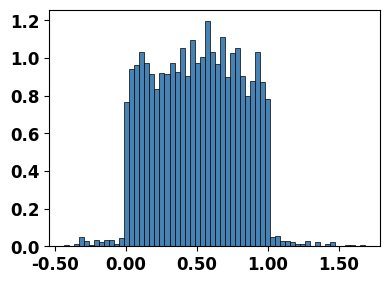

Sparsity: 88.11% (zeros 3609/4096)


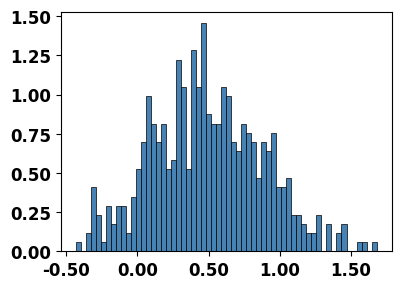

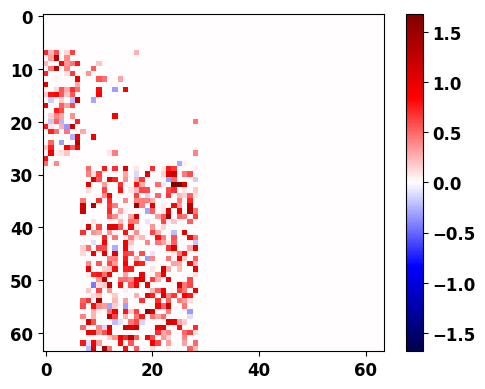

Sparsity: 88.11% (zeros 3609/4096)


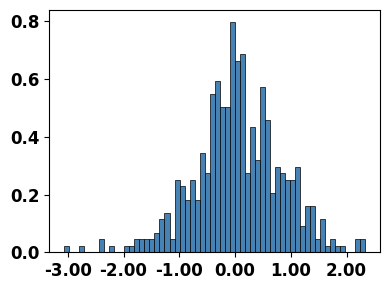

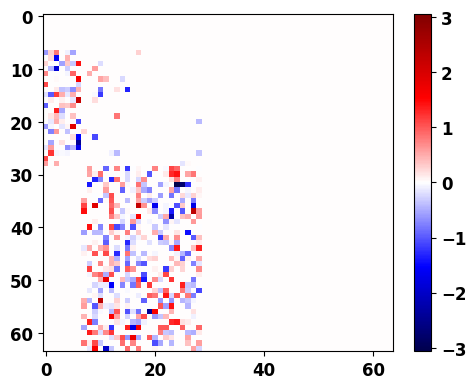

In [72]:


import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import numpy as np

def flatten_dict(d, prefix=""):
    flat = {}
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_dict(v, prefix=name + "."))
        else:
            flat[name] = v
    return flat

def find_key_endswith(flat_dict, suffix):
    for k in flat_dict.keys():
        if k.endswith(suffix):
            return k
    return None

def plot_params(
    checkpoint_path: str,
    include_keywords=None,
    max_plots: int = 12,
    bins: int = 60,
    tick_fontsize: int = 12,
    flag: bool = False,
):
    # 1. モデルロード
    state = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state and isinstance(state["state_dict"], dict):
        state = state["state_dict"]

    # 2. 平坦化
    flat = flatten_dict(state)
    print(f"Total keys found: {len(flat)}")

    # 3. フィルタと収集
    def use_param(name):
        if not include_keywords:
            return True
        return any(k in name for k in include_keywords)

    items = [(n, p) for n, p in flat.items()
             if torch.is_tensor(p) and torch.is_floating_point(p) and use_param(n)]
    if not items:
        print("警告: 該当するパラメータが見つかりませんでした。キーワードを確認してください。")
        return

    # 4. ヒストグラム群（PART 1）
    items = items[:max_plots]
    n = len(items)
    cols = min(3, n)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(4*cols, 3*rows))
    for i, (name, tensor) in enumerate(items, 1):
        t_np = tensor.detach().cpu().flatten().numpy()
        ax = plt.subplot(rows, cols, i)
        ax.hist(t_np, bins=bins, density=True, color="steelblue", edgecolor="black", linewidth=0.5, alpha=1.0)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    plt.tight_layout()
    plt.show()

    # 5. Sparsity: w * mask（PART 2）
    w_key = find_key_endswith(flat, "rnn_cell.w")
    mask_key = find_key_endswith(flat, "rnn_cell.sparsity_mask")
    erev_key = find_key_endswith(flat, "rnn_cell.erev")
    if w_key and mask_key and flag:
        w = flat[w_key]
        mask = flat[mask_key]
        effective_weights = w * mask

        total_params = effective_weights.numel()
        zero_params = (effective_weights == 0).sum().item()
        sparsity_percent = (zero_params / total_params) * 100
        print(f"Sparsity: {sparsity_percent:.2f}% (zeros {zero_params}/{total_params})")

        # 図1: 非ゼロのみヒスト
        nz = effective_weights[effective_weights != 0]
        plt.figure(figsize=(4, 3))
        ax = plt.gca()
        if nz.numel() > 0:
            ax.hist(nz.detach().cpu().flatten().numpy(), bins=bins, density=True,
                    color="steelblue", edgecolor="black", linewidth=0.5, alpha=1.0)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        plt.tight_layout()
        plt.show()

        # 図2: ヒートマップ
        plt.figure(figsize=(5, 4))
        ax = plt.gca()
        w_mat = effective_weights.detach().cpu().numpy()
        abs_max = np.abs(w_mat).max() if w_mat.size > 0 else 1.0
        im = ax.imshow(w_mat, cmap='seismic', vmin=-abs_max, vmax=abs_max,
                       interpolation='nearest', aspect='auto')
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        for label in cbar.ax.get_yticklabels():
            label.set_fontweight("bold")
        plt.tight_layout()
        plt.show()
    else:
        print("Sparsity mask or weights not found.")
    
    if w_key and mask_key and erev_key and flag:
        w = flat[w_key]
        mask = flat[mask_key]
        erev = flat[erev_key]
        effective_weights = w * mask
        effective_weights = effective_weights * erev

        total_params = effective_weights.numel()
        zero_params = (effective_weights == 0).sum().item()
        sparsity_percent = (zero_params / total_params) * 100
        print(f"Sparsity: {sparsity_percent:.2f}% (zeros {zero_params}/{total_params})")

        # 図1: 非ゼロのみヒスト
        nz = effective_weights[effective_weights != 0]
        plt.figure(figsize=(4, 3))
        ax = plt.gca()
        if nz.numel() > 0:
            ax.hist(nz.detach().cpu().flatten().numpy(), bins=bins, density=True,
                    color="steelblue", edgecolor="black", linewidth=0.5, alpha=1.0)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        plt.tight_layout()
        plt.show()

        # 図2: ヒートマップ
        plt.figure(figsize=(5, 4))
        ax = plt.gca()
        w_mat = effective_weights.detach().cpu().numpy()
        abs_max = np.abs(w_mat).max() if w_mat.size > 0 else 1.0
        im = ax.imshow(w_mat, cmap='seismic', vmin=-abs_max, vmax=abs_max,
                       interpolation='nearest', aspect='auto')
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        for label in cbar.ax.get_yticklabels():
            label.set_fontweight("bold")
        plt.tight_layout()
        plt.show()

plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.w"], flag=True)

Total keys found: 130


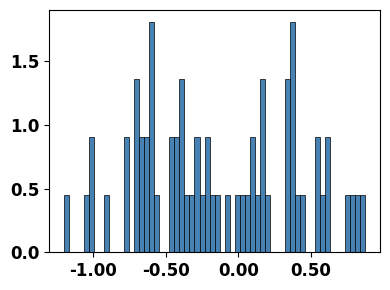

Sparsity mask or weights not found.
Total keys found: 130


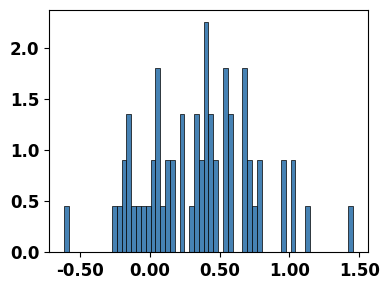

Sparsity mask or weights not found.
Total keys found: 130


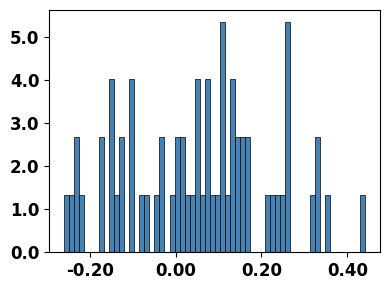

Sparsity mask or weights not found.


In [75]:
# Digital RRAM
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.cm"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.gleak"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.vleak"])